# Phase 4 MongoDB Queries and Visualizations

This notebook connects to MongoDB, executes the MongoDB queries for the research questions, retrieves and processes results, and creates visualizations for analysis.

In [1]:
from pymongo import MongoClient
import matplotlib.pyplot as plt

In [2]:
MONGO_URI = "mongodb://localhost:27017"
DATABASE_NAME = "mjain08"
COLLECTION_NAME = "movies"

In [3]:
#Query 1: compute disagreement

pipeline_q1 = [
    {
        "$project": {
            "title": 1,
            "movielens_rating": "$movielens.avg_rating",
            "imdb_rating": "$imdb.avg_rating",
            "disagreement": "$derived_metrics.disagreement"
        }
    }
]

In [4]:
def run_query_1(collection):
    results = list(collection.aggregate(pipeline_q1))
    return results

In [5]:
def plot_q1(results):
    disagreements = [
        doc["disagreement"]
        for doc in results
        if "disagreement" in doc and doc["disagreement"] is not None
    ]

    plt.figure()
    plt.hist(disagreements)
    plt.xlabel("Disagreement (|IMDb - MovieLens|)")
    plt.ylabel("Number of Movies")
    plt.title("Distribution of Rating Disagreement")
    plt.show()

In [6]:
#Query 2: engagement vs disagreement

pipeline_q2 = [
    {
        "$project": {
            "title": 1,
            "tag_count": "$movielens.tag_count",
            "imdb_votes": "$imdb.num_votes",
            "disagreement": "$derived_metrics.disagreement"
        }
    }
]

In [7]:
def run_query_2(collection):
    results = list(collection.aggregate(pipeline_q2))
    return results

In [10]:
def plot_q2(results):
    filtered = [
        doc for doc in results
        if "imdb_votes" in doc
        and "disagreement" in doc
        and doc["imdb_votes"] is not None
        and doc["disagreement"] is not None
    ]

    imdb_votes = [doc["imdb_votes"] for doc in filtered]
    disagreements = [doc["disagreement"] for doc in filtered]

    plt.figure()
    plt.scatter(imdb_votes, disagreements)
    plt.xscale("log")
    plt.xlabel("IMDb Vote Count (log scale)")
    plt.ylabel("Disagreement (|IMDb - MovieLens|)")
    plt.title("IMDb Vote Count vs Rating Disagreement")
    plt.show()

In [13]:
def plot_q2_tagcount(results):
    filtered = [
        doc for doc in results
        if "tag_count" in doc
        and "disagreement" in doc
        and doc["tag_count"] is not None
        and doc["disagreement"] is not None
        and doc["tag_count"] > 0
    ]

    tag_counts = [doc["tag_count"] for doc in filtered]
    disagreements = [doc["disagreement"] for doc in filtered]

    plt.figure()
    plt.scatter(tag_counts, disagreements)
    plt.xscale("log")
    plt.xlabel("MovieLens Tag Count (log scale)")
    plt.ylabel("Disagreement (|IMDb - MovieLens|)")
    plt.title("MovieLens Tag Count vs Rating Disagreement")
    plt.show()

## Step 5–6: MongoDB Research Queries and Visualizations

This section executes the MongoDB queries for the two research questions and generates one visualization for each question.

- Query 1: examines rating consistency between MovieLens and IMDb using the disagreement metric.
- Query 2: examines whether user engagement (MovieLens tag counts and IMDb vote counts) is related to disagreement magnitude.

Sample Query 1 results:
{'_id': ObjectId('69d890b0cb761c0f4c83ff23'), 'title': 'Like a Boss (2020)', 'movielens_rating': 2.0964912280701755, 'imdb_rating': 4.7, 'disagreement': 2.6035087719298247}
{'_id': ObjectId('69d890b0cb761c0f4c83ff24'), 'title': "My Boyfriend's Meds (2020)", 'movielens_rating': 1.9166666666666667, 'imdb_rating': 4.6, 'disagreement': 2.6833333333333327}
{'_id': ObjectId('69d890b0cb761c0f4c83ff25'), 'title': 'Rogue Warfare: Death of a Nation (2020)', 'movielens_rating': 1.5, 'imdb_rating': 3.3, 'disagreement': 1.7999999999999998}
{'_id': ObjectId('69d890b0cb761c0f4c83ff26'), 'title': 'The Bet (2020)', 'movielens_rating': 0.5, 'imdb_rating': 4.2, 'disagreement': 3.7}
{'_id': ObjectId('69d890b0cb761c0f4c83ff27'), 'title': "Odio l'estate (2020)", 'movielens_rating': 3.2083333333333335, 'imdb_rating': 6.7, 'disagreement': 3.4916666666666667}


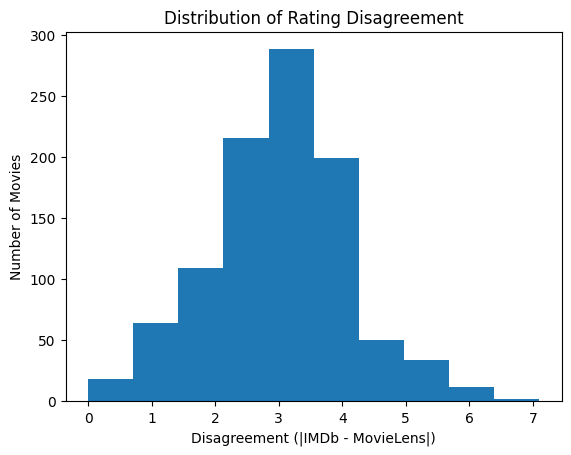


Sample Query 2 results:
{'_id': ObjectId('69d890b0cb761c0f4c83ff23'), 'title': 'Like a Boss (2020)', 'tag_count': 9, 'imdb_votes': 16156, 'disagreement': 2.6035087719298247}
{'_id': ObjectId('69d890b0cb761c0f4c83ff24'), 'title': "My Boyfriend's Meds (2020)", 'tag_count': 0, 'imdb_votes': 541, 'disagreement': 2.6833333333333327}
{'_id': ObjectId('69d890b0cb761c0f4c83ff25'), 'title': 'Rogue Warfare: Death of a Nation (2020)', 'tag_count': 0, 'imdb_votes': 488, 'disagreement': 1.7999999999999998}
{'_id': ObjectId('69d890b0cb761c0f4c83ff26'), 'title': 'The Bet (2020)', 'tag_count': 0, 'imdb_votes': 237, 'disagreement': 3.7}
{'_id': ObjectId('69d890b0cb761c0f4c83ff27'), 'title': "Odio l'estate (2020)", 'tag_count': 0, 'imdb_votes': 4275, 'disagreement': 3.4916666666666667}


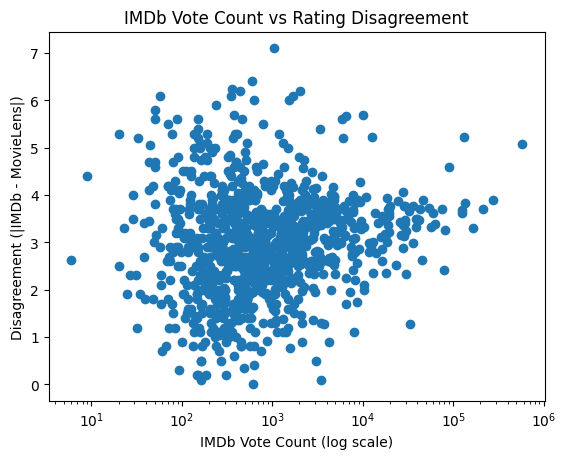

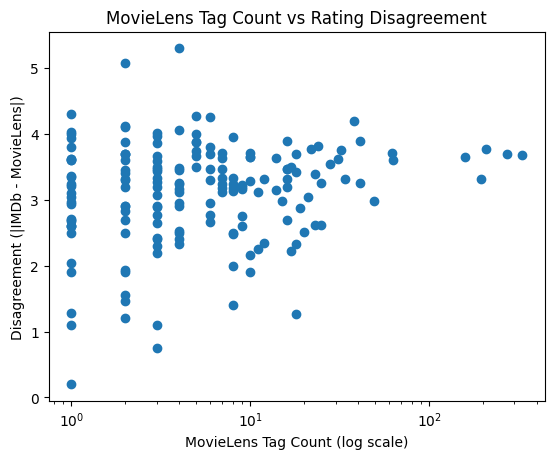

In [14]:
client = MongoClient(MONGO_URI)
db = client[DATABASE_NAME]
collection = db[COLLECTION_NAME]


q1_results = run_query_1(collection)
print("Sample Query 1 results:")
for row in q1_results[:5]:
    print(row)


plot_q1(q1_results)


q2_results = run_query_2(collection)
print("\nSample Query 2 results:")
for row in q2_results[:5]:
    print(row)


plot_q2(q2_results)
plot_q2_tagcount(q2_results)